# Workflow Pattern: Prompt Chaining / Sequential

### Prompt Chaining

Prompt Chaining is a workflow design pattern where complex tasks are decomposed into a sequence of LLM (Large Language Model) calls. Each step depends on the output of the previous one, allowing for step-by-step refinement or evolution of the data being processed.

#### Typical Structure:
- **Step 1:** Initial LLM prompt (for example, generate a draft)
- **Step 2:** Refinement prompt (for example, improve style, tone)
- **Step 3:** Evaluation or formatting (for example, convert to specific format or assess quality)

---
#### Use Cases:
- Generating blog posts or marketing copy step-by-step (idea → outline → paragraph → polish)
- Automated report generation (for example, extract → analyze → summarize)
- Educational content creation (for example, topic → questions → answers → explanations)

<img src='../assets/prompt-chaining.png' />

## Prompt Chaining — Job Application Assistant


In [ ]:
# %%capture
# %pip install langchain-openai==0.3.27
# %pip install langgraph==0.6.6

In [2]:
from langgraph.graph import StateGraph, END,START
from typing import TypedDict
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langgraph.graph import END, StateGraph
from IPython.display import Image, display

In [3]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [4]:
class ChainState(TypedDict):
    job_description: str
    resume_summary: str
    cover_letter: str

In [ ]:
# Resume Summary Agent
def generate_resume_summary(state: ChainState) -> ChainState:
    prompt = f"""
You're a resume assistant. Read the following job description and summarize the key qualifications and experience the ideal candidate should have, phrased as if from the perspective of a strong applicant's resume summary.

Job Description:
{state['job_description']}
"""

    response = llm.invoke(prompt)

    return {**state, "resume_summary": response.content} # it could also work without "**state"

In [6]:
# Generate Cover Letter Agent
def generate_cover_letter(state: ChainState) -> ChainState:
    prompt = f"""
        You're a cover letter writing assistant. Using the resume summary below, write a professional and personalized cover letter for the following job.

        Resume Summary:
        {state['resume_summary']}

        Job Description:
        {state['job_description']}
    """

    response = llm.invoke(prompt)

    return {**state, "cover_letter": response.content}

In [8]:
workflow = StateGraph(ChainState)

workflow.add_node("generate_resume_summary", generate_resume_summary)
workflow.add_node("generate_cover_letter", generate_cover_letter)

# workflow.add_edge(START, "generate_resume_summary") # same as below
workflow.set_entry_point("generate_resume_summary")
workflow.add_edge("generate_resume_summary", "generate_cover_letter")
workflow.set_finish_point("generate_cover_letter")
# workflow.add_edge("generate_cover_letter", END) # same as above

app = workflow.compile()

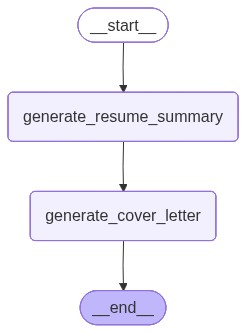

In [9]:
display(Image(app.get_graph().draw_mermaid_png()))


In [10]:
input_state = {
        "job_description": "We are looking for a data scientist with experience in machine learning, NLP, and Python. Prior work with large datasets and experience deploying models into production is required."
}

result = app.invoke(input_state)

In [13]:
result

{'job_description': 'We are looking for a data scientist with experience in machine learning, NLP, and Python. Prior work with large datasets and experience deploying models into production is required.',
 'resume_summary': 'Results-driven Data Scientist with extensive experience in machine learning and natural language processing (NLP). Proficient in Python and skilled in handling large datasets, I have a proven track record of deploying machine learning models into production environments. Adept at transforming complex data into actionable insights, I am committed to leveraging my expertise to drive data-driven decision-making and enhance operational efficiency.',
 'cover_letter': "[Your Name]  \n[Your Address]  \n[City, State, Zip]  \n[Your Email]  \n[Your Phone Number]  \n[Date]  \n\n[Hiring Manager's Name]  \n[Company Name]  \n[Company Address]  \n[City, State, Zip]  \n\nDear [Hiring Manager's Name],\n\nI am writing to express my interest in the Data Scientist position at [Company

In [11]:
result['resume_summary']

'Results-driven Data Scientist with extensive experience in machine learning and natural language processing (NLP). Proficient in Python and skilled in handling large datasets, I have a proven track record of deploying machine learning models into production environments. Adept at transforming complex data into actionable insights, I am committed to leveraging my expertise to drive data-driven decision-making and enhance operational efficiency.'

In [12]:
result['cover_letter']

"[Your Name]  \n[Your Address]  \n[City, State, Zip]  \n[Your Email]  \n[Your Phone Number]  \n[Date]  \n\n[Hiring Manager's Name]  \n[Company Name]  \n[Company Address]  \n[City, State, Zip]  \n\nDear [Hiring Manager's Name],\n\nI am writing to express my interest in the Data Scientist position at [Company Name] as advertised. With a strong background in machine learning and natural language processing (NLP), along with extensive experience in Python, I am excited about the opportunity to contribute to your team and help drive data-driven decision-making within your organization.\n\nIn my previous roles, I have successfully handled large datasets, transforming complex data into actionable insights that support strategic initiatives. My hands-on experience in deploying machine learning models into production environments has equipped me with a deep understanding of the end-to-end process, from model development to implementation. I am particularly passionate about using data to enhance